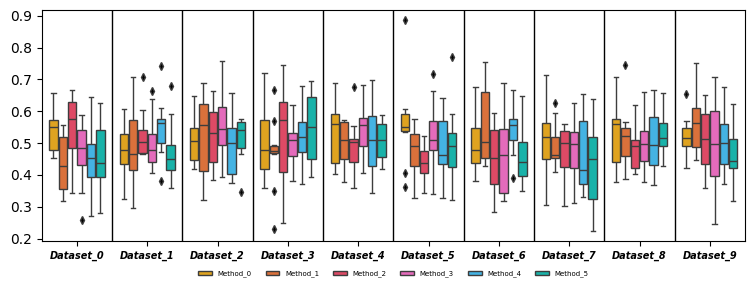

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the benchmark data
np.random.seed(42) # set random seed for reproducibility
method_list = ["Method_{}".format(i) for i in range(6)]
dataset_list = ["Dataset_{}".format(i) for i in range(13)]
metric_list = ["Metric_{}".format(i) for i in range(4)]
experiment_list = [i for i in range(1, 11)]
result_data = []
for method in method_list:
    for dataset in dataset_list:
        for metric in metric_list:
            results = np.random.normal(loc=0.5, scale=0.1, size=len(experiment_list))
            for exp_num, result in enumerate(results, 1):
                result_data.append([method, dataset, metric, exp_num, result])
df_simulated = pd.DataFrame(result_data, columns=["Method", "Dataset", "Metric", "Experiment", "Result"])
df_pivoted = df_simulated.pivot_table(index=["Method", "Dataset", "Experiment"], columns="Metric", values="Result").reset_index() # Pivot the DataFrame to convert 'Metric' values into columns
df_pivoted.columns.name = None  # Remove the columns name (from pivoting)
# df_pivoted.to_csv('./result.csv')
# df = pd.read_csv('./result.csv', index_col=0)
df = df_pivoted
df = df.melt(id_vars=["Method", "Dataset", "Experiment"], var_name="Metric", value_name="Result") # reverse the above pivot, melt the dataframe to have the metrics in a single column
df = df[df['Metric'] == 'Metric_0'] # select the metric to plot
df = df[~df['Dataset'].isin(['Dataset_10', 'Dataset_11', 'Dataset_12'])] # delete Dataset_10, Dataset_11, and Dataset_12.

# Plot the results
fig, ax = plt.subplots(figsize=(9, 3))
colors = ['#dfa320', '#da713b', '#dd4a65', '#e46bbb', '#44b3e3', '#19b2a9']
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
sns.boxplot(x="Dataset", y="Result", hue="Method", data=df, dodge='auto', width=0.8, gap=0.1, saturation=1, palette=colors, flierprops=dict(marker='d', markerfacecolor='black', markersize=4), linewidth=1)   
plt.xticks(fontsize=7, fontstyle='italic', fontweight='bold')
for i in range(1, len(df["Dataset"].unique())):
    ax.axvline(x=i - 0.5, color='black', linestyle='-', linewidth=1)
ax.set_title(''); ax.set_xlabel(''); ax.set_ylabel('')
ax.spines['top'].set_visible(True); ax.spines['top'].set_color('black')
ax.spines['right'].set_visible(True); ax.spines['right'].set_color('black')
ax.spines['bottom'].set_visible(True); ax.spines['bottom'].set_color('black')
ax.spines['left'].set_visible(True); ax.spines['left'].set_color('black')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), title="", ncol=6, frameon=False, fontsize=5)
# plt.legend().set_visible(False)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

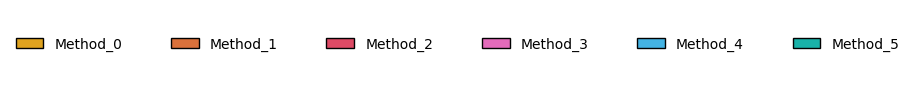

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

colors = ['#dfa320', '#da713b', '#dd4a65', '#e46bbb', '#44b3e3', '#19b2a9', '#4b9b3f']
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
labels = ['Method_0', 'Method_1', 'Method_2', 'Method_3', 'Method_4', 'Method_5']

fig, ax = plt.subplots(figsize=(10, 1))
legend_elements = [Patch(facecolor=color, edgecolor='black', label=label) for color, label in zip(colors, labels)]
legend = ax.legend(handles=legend_elements, loc='center', frameon=False, edgecolor='black', markerscale=10.5, fontsize=10, ncol=7, columnspacing=3.5)

ax.set_axis_off() # hide the axis
plt.tight_layout()
plt.show()

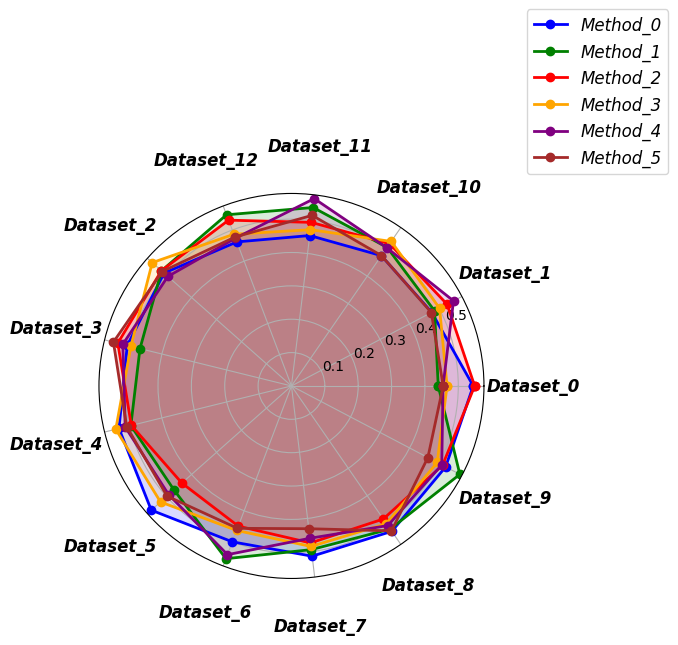

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate the benchmark data
np.random.seed(42) # set random seed for reproducibility
method_list = ["Method_{}".format(i) for i in range(6)]
dataset_list = ["Dataset_{}".format(i) for i in range(13)]
metric_list = ["Metric_{}".format(i) for i in range(4)]
experiment_list = [i for i in range(1, 11)]
result_data = []
for method in method_list:
    for dataset in dataset_list:
        for metric in metric_list:
            results = np.random.normal(loc=0.5, scale=0.1, size=len(experiment_list))
            for exp_num, result in enumerate(results, 1):
                result_data.append([method, dataset, metric, exp_num, result])
df_simulated = pd.DataFrame(result_data, columns=["Method", "Dataset", "Metric", "Experiment", "Result"])
df_pivoted = df_simulated.pivot_table(index=["Method", "Dataset", "Experiment"], columns="Metric", values="Result").reset_index() # Pivot the DataFrame to convert 'Metric' values into columns
df_pivoted.columns.name = None  # Remove the columns name (from pivoting)
# df_pivoted.to_csv('./result.csv')
# df = pd.read_csv('./result.csv', index_col=0)
df = df_pivoted
df = df.melt(id_vars=["Method", "Dataset", "Experiment"], var_name="Metric", value_name="Result") # melt the dataframe to have the metrics in a single column
df = df[df['Metric'] == 'Metric_0'] # select the metric to plot
df = df.groupby(['Method', 'Dataset']).agg({'Result': ['mean', 'std']}).reset_index() # calculate the mean and standard deviation of the results
df.columns = df.columns.droplevel(1)
df.columns = ['Method', 'Dataset', 'Mean', 'STD']
df = df[['Method', 'Dataset', 'Mean']]
df = df.sort_values(by='Dataset')
df = df.reset_index(drop=True)
methods = df['Method'].unique()
datasets = df['Dataset'].unique()
methods = sorted(methods)
datasets = sorted(datasets)
num_vars = len(datasets)
plot_data = [df[df['Method'] == method]['Mean'].values for method in methods]

# Plot the results
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
colors = ['b', 'g', 'r', 'orange', 'purple', 'brown']
for i, color in enumerate(colors):
    values = plot_data[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, label=methods[i], marker='o')
    ax.fill(angles, values, color=color, alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(datasets, fontsize=12, fontweight='bold', ha='center', va='center', fontdict={'style': 'italic'})
ax.tick_params(axis='x', pad=25)
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.5), fontsize=12, prop={'size': 12, 'style': 'italic'})
# plt.title("Radar Chart for Six Methods with Four Metrics", y=1.1)
plt.show()

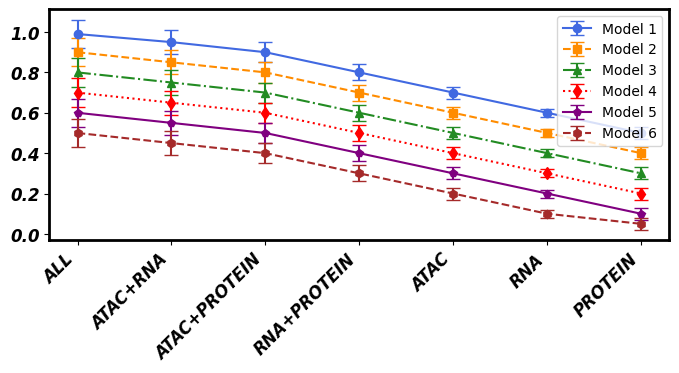

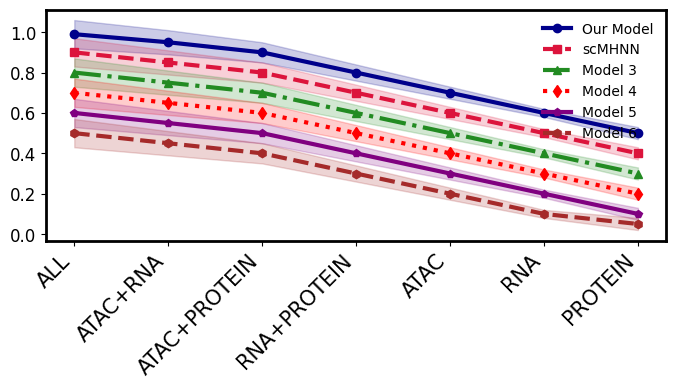

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate the benchmark data
np.random.seed(42) # set random seed for reproducibility
method_list = ["Method_{}".format(i) for i in range(6)]
dataset_list = ["ATAC", "RNA", "PROTEIN", "ATAC+RNA", "ATAC+PROTEIN", "RNA+PROTEIN", "ATAC+RNA+PROTEIN"]
metric_list = ["Metric_{}".format(i) for i in range(4)]
experiment_list = [i for i in range(1, 11)]
result_data = []
for method in method_list:
    for dataset in dataset_list:
        for metric in metric_list:
            results = np.random.normal(loc=0.5, scale=0.1, size=len(experiment_list))
            for exp_num, result in enumerate(results, 1):
                result_data.append([method, dataset, metric, exp_num, result])
df_simulated = pd.DataFrame(result_data, columns=["Method", "Dataset", "Metric", "Experiment", "Result"])
df_pivoted = df_simulated.pivot_table(index=["Method", "Dataset", "Experiment"], columns="Metric", values="Result").reset_index() # Pivot the DataFrame to convert 'Metric' values into columns
df_pivoted.columns.name = None  # Remove the columns name (from pivoting)
# df_pivoted.to_csv('./result.csv')
# df = pd.read_csv('./result.csv', index_col=0)
df = df_pivoted
df = df.melt(id_vars=["Method", "Dataset", "Experiment"], var_name="Metric", value_name="Result") # melt the dataframe to have the metrics in a single column
df = df[df['Metric'] == 'Metric_0'] # select the metric to plot
df = df[~df['Dataset'].isin(['Dataset_10', 'Dataset_11', 'Dataset_12'])] # delete Dataset_10, Dataset_11, and Dataset_12.
df = df.groupby(['Method', 'Dataset']).agg({'Result': ['mean', 'std']}).reset_index() # group by method and dataset and calculate the mean and std
mean_df = df.pivot(index='Method', columns='Dataset', values=('Result', 'mean')).reset_index()
std_df = df.pivot(index='Method', columns='Dataset', values=('Result', 'std')).reset_index()
mean_df = mean_df[['Method', 'ATAC+RNA+PROTEIN', 'ATAC+RNA', 'ATAC+PROTEIN', 'RNA+PROTEIN', 'ATAC', 'RNA', 'PROTEIN']]
std_df = std_df[['Method', 'ATAC+RNA+PROTEIN', 'ATAC+RNA', 'ATAC+PROTEIN', 'RNA+PROTEIN', 'ATAC', 'RNA', 'PROTEIN']]
mean_df.columns.name = None
std_df.columns.name = None
mean_df.columns = ['Method', 'ALL', 'ATAC+RNA', 'ATAC+PROTEIN', 'RNA+PROTEIN', 'ATAC', 'RNA', 'PROTEIN']
std_df.columns = ['Method', 'ALL', 'ATAC+RNA', 'ATAC+PROTEIN', 'RNA+PROTEIN', 'ATAC', 'RNA', 'PROTEIN']

x_labels = ['ALL', 'ATAC+RNA', 'ATAC+PROTEIN', 'RNA+PROTEIN', 'ATAC', 'RNA', 'PROTEIN']
performance_model_1 = mean_df.loc[mean_df['Method'] == 'Method_0', x_labels].values[0]
performance_model_2 = mean_df.loc[mean_df['Method'] == 'Method_1', x_labels].values[0]
performance_model_3 = mean_df.loc[mean_df['Method'] == 'Method_2', x_labels].values[0]
performance_model_4 = mean_df.loc[mean_df['Method'] == 'Method_3', x_labels].values[0]
performance_model_5 = mean_df.loc[mean_df['Method'] == 'Method_4', x_labels].values[0]
performance_model_6 = mean_df.loc[mean_df['Method'] == 'Method_5', x_labels].values[0]
error_model_1 = std_df.loc[std_df['Method'] == 'Method_0', x_labels].values[0]
error_model_2 = std_df.loc[std_df['Method'] == 'Method_1', x_labels].values[0]
error_model_3 = std_df.loc[std_df['Method'] == 'Method_2', x_labels].values[0]
error_model_4 = std_df.loc[std_df['Method'] == 'Method_3', x_labels].values[0]
error_model_5 = std_df.loc[std_df['Method'] == 'Method_4', x_labels].values[0]
error_model_6 = std_df.loc[std_df['Method'] == 'Method_5', x_labels].values[0]
performance_model_1 = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99])[::-1]
performance_model_2 = np.array([0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9])[::-1]
performance_model_3 = np.array([0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8])[::-1]
performance_model_4 = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.65, 0.7])[::-1]
performance_model_5 = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.55, 0.6])[::-1]
performance_model_6 = np.array([0.05, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5])[::-1]
error_model_1 = np.array([0.03, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07])[::-1]
error_model_2 = np.array([0.03, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07])[::-1]
error_model_3 = np.array([0.03, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07])[::-1]
error_model_4 = np.array([0.03, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07])[::-1]
error_model_5 = np.array([0.03, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07])[::-1]
error_model_6 = np.array([0.03, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07])[::-1]

# Plot the results
plt.figure(figsize=(8, 3))
plt.errorbar(x_labels, performance_model_1, yerr=error_model_1, marker='o', linestyle='-', color='royalblue', label='Model 1', capsize=5)
plt.errorbar(x_labels, performance_model_2, yerr=error_model_2, marker='s', linestyle='--', color='darkorange', label='Model 2', capsize=5)
plt.errorbar(x_labels, performance_model_3, yerr=error_model_3, marker='^', linestyle='-.', color='forestgreen', label='Model 3', capsize=5)
plt.errorbar(x_labels, performance_model_4, yerr=error_model_4, marker='d', linestyle=':', color='red', label='Model 4', capsize=5)
plt.errorbar(x_labels, performance_model_5, yerr=error_model_5, marker='p', linestyle='-', color='purple', label='Model 5', capsize=5)
plt.errorbar(x_labels, performance_model_6, yerr=error_model_6, marker='h', linestyle='--', color='brown', label='Model 6', capsize=5)
plt.xticks(rotation=45, ha='right', fontsize=12, fontstyle='italic', fontweight='bold')
plt.yticks(fontsize=12, fontstyle='italic', fontweight='bold')
ax = plt.gca(); ax.spines['top'].set_linewidth(2); ax.spines['right'].set_linewidth(2); ax.spines['left'].set_linewidth(2); ax.spines['bottom'].set_linewidth(2)
plt.legend()
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(x_labels, performance_model_1, marker='o', linestyle='-', color='darkblue', label='Our Model', linewidth=3)
plt.fill_between(x_labels, np.array(performance_model_1) - np.array(error_model_1), np.array(performance_model_1) + np.array(error_model_1), color='darkblue', alpha=0.2)
plt.plot(x_labels, performance_model_2, marker='s', linestyle='--', color='crimson', label='scMHNN', linewidth=3)
plt.fill_between(x_labels, np.array(performance_model_2) - np.array(error_model_2), np.array(performance_model_2) + np.array(error_model_2), color='crimson', alpha=0.2)
plt.plot(x_labels, performance_model_3, marker='^', linestyle='-.', color='forestgreen', label='Model 3', linewidth=3)
plt.fill_between(x_labels, np.array(performance_model_3) - np.array(error_model_3), np.array(performance_model_3) + np.array(error_model_3), color='forestgreen', alpha=0.2)
plt.plot(x_labels, performance_model_4, marker='d', linestyle=':', color='red', label='Model 4', linewidth=3)
plt.fill_between(x_labels, np.array(performance_model_4) - np.array(error_model_4), np.array(performance_model_4) + np.array(error_model_4), color='red', alpha=0.2)
plt.plot(x_labels, performance_model_5, marker='p', linestyle='-', color='purple', label='Model 5', linewidth=3)
plt.fill_between(x_labels, np.array(performance_model_5) - np.array(error_model_5), np.array(performance_model_5) + np.array(error_model_5), color='purple', alpha=0.2)
plt.plot(x_labels, performance_model_6, marker='h', linestyle='--', color='brown', label='Model 6', linewidth=3)
plt.fill_between(x_labels, np.array(performance_model_6) - np.array(error_model_6), np.array(performance_model_6) + np.array(error_model_6), color='brown', alpha=0.2)
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=12)
ax = plt.gca(); ax.spines['top'].set_linewidth(2); ax.spines['right'].set_linewidth(2); ax.spines['left'].set_linewidth(2); ax.spines['bottom'].set_linewidth(2)
plt.legend(loc='upper right', bbox_to_anchor=(1, 1), ncol=1, frameon=False, fontsize=10) #prop = {'weight':'bold', 'size':20})
plt.show()

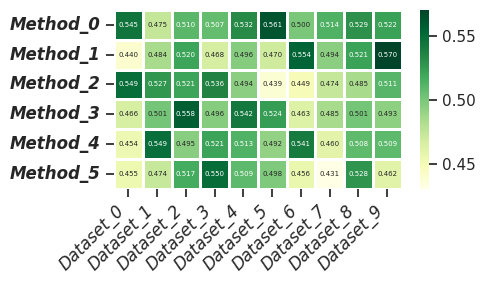

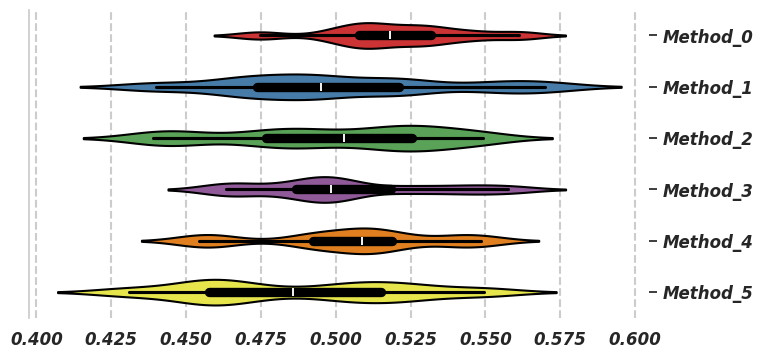

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the benchmark data
np.random.seed(42) # set random seed for reproducibility
method_list = ["Method_{}".format(i) for i in range(6)]
dataset_list = ["Dataset_{}".format(i) for i in range(13)]
metric_list = ["Metric_{}".format(i) for i in range(4)]
experiment_list = [i for i in range(1, 11)]
result_data = []
for method in method_list:
    for dataset in dataset_list:
        for metric in metric_list:
            results = np.random.normal(loc=0.5, scale=0.1, size=len(experiment_list))
            for exp_num, result in enumerate(results, 1):
                result_data.append([method, dataset, metric, exp_num, result])
df_simulated = pd.DataFrame(result_data, columns=["Method", "Dataset", "Metric", "Experiment", "Result"])
df_pivoted = df_simulated.pivot_table(index=["Method", "Dataset", "Experiment"], columns="Metric", values="Result").reset_index() # Pivot the DataFrame to convert 'Metric' values into columns
df_pivoted.columns.name = None  # Remove the columns name (from pivoting)
# df_pivoted.to_csv('./result.csv')
# df = pd.read_csv('./result.csv', index_col=0)
df = df_pivoted
df = df.melt(id_vars=["Method", "Dataset", "Experiment"], var_name="Metric", value_name="Result") # melt the dataframe to have the metrics in a single column
df = df[df['Metric'] == 'Metric_0'] # select the metric to plot
df = df[~df['Dataset'].isin(['Dataset_10', 'Dataset_11', 'Dataset_12'])] # delete Dataset_10, Dataset_11, and Dataset_12.
df = df.groupby(['Method', 'Dataset'])['Result'].mean().reset_index()

# Plot the results
sns.set_theme(style="whitegrid")
heatmap_data = df.pivot(index='Method', columns='Dataset', values='Result')
heatmap_data.columns.name = None
heatmap_data.index.name = None
heatmap_data
plt.figure(figsize=(5, 3))
sns.heatmap(heatmap_data, annot=True, cmap="YlGn", fmt=".3f", linecolor='white', linewidths=2, square=False, annot_kws={"size": 5}) # Increasing linewidth and setting square=True for square cells
plt.xticks(fontsize=12, rotation=45, ha="right", style='italic')
plt.yticks(fontsize=12, rotation=0, style='italic', fontweight='bold')
plt.tick_params(left=True, bottom=True)
plt.tight_layout()
plt.show()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))
sns.violinplot(x='Result', y='Method', data=df, palette="Set1", hue='Method', bw_adjust=0.5, cut=2, linewidth=1.5, width=0.5, density_norm='width', edgecolor='black', dodge=False)
plt.xlabel('')
plt.ylabel('')
plt.gca().yaxis.tick_right()
plt.yticks(fontsize=12, style='italic', rotation=0, fontweight='bold')
plt.xticks(fontsize=12, style='italic', rotation=0, fontweight='bold')
# plt.box(False)
sns.despine(top=True, bottom=True)
plt.grid(True, axis='x', linestyle='--', linewidth=1.5)
# plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

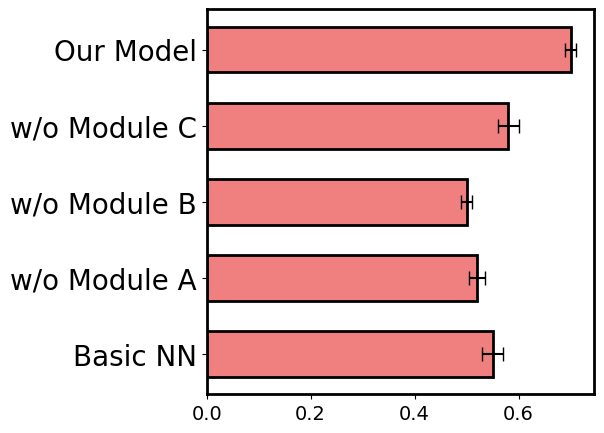

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# 创建带误差棒的条形图，换颜色并加粗线条
configurations = ['Basic NN', 'w/o Module A', 'w/o Module B', 'w/o Module C', 'Our Model']  # 新的配置标签
performance = np.array([0.75, 0.72, 0.70, 0.78, 0.9]) - 0.2
error = np.array([0.02, 0.015, 0.01, 0.02, 0.01])  # 误差

fig, ax = plt.subplots(figsize=(5, 5))
ax.barh(configurations, performance, xerr=error, color='lightcoral', 
        capsize=5, edgecolor='black', linewidth=2, height=0.6)
# ax.set_xlabel('Accuracy')
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=14)

# 删除网格线
ax.grid(False)

# # 左右翻转
# ax.invert_xaxis()

# # 将 y 轴刻度标签移到右边
# ax.yaxis.tick_right()

# 添加上方和右边的线，并加粗线条
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['top'].set_linewidth(2)  # 加粗上方的线
ax.spines['right'].set_linewidth(2)  # 加粗右边的线
ax.spines['left'].set_linewidth(2)  # 加粗左边的线
ax.spines['bottom'].set_linewidth(2)  # 加粗下方的线

# 保留纵轴标签
ax.set_title('')  # 删除标题
# ax.set_xlim(0, 1)  # 设置 x 轴范围

plt.show()